# Manufacturing Defect Analytics
### Hack-o-Week Project — Week 3 & 4 (Python, NumPy, Pandas, Visualization + ML)

**Dataset:** [Predicting Manufacturing Defects Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predicting-manufacturing-defects-dataset)
(Kaggle, by Rabie El Kharoua) — 3,240 production records with 16 process
parameters and a binary `DefectStatus` target (1 = defective run, 0 = good run).

**Why this dataset:** it's real production-floor telemetry (production
volume/cost, supplier quality, maintenance hours, downtime %, energy use,
safety incidents, etc.) rather than a toy dataset — a genuine fit for
analysing what drives manufacturing quality and efficiency, which lines up
with heavy-industry AI applications (steel, aluminum, foundries).

**What this notebook covers:**
1. Loading & inspecting the raw data
2. Cleaning & feature engineering (`src/pipeline.py` — OOP pipeline)
3. Exploratory Data Analysis with Matplotlib & Seaborn
4. A machine learning classifier to predict `DefectStatus` from process parameters
5. Business takeaways a plant manager could act on


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pipeline import ManufacturingDataset

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Load & Inspect Raw Data

In [2]:
raw = pd.read_csv('../data/manufacturing_defect_dataset.csv')
print(f"Shape: {raw.shape}")
raw.head()


Shape: (3240, 17)


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [3]:
raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost  3240 non-n

In [4]:
print("Missing values:", raw.isna().sum().sum())
print("Duplicate rows :", raw.duplicated().sum())
print()
print("Target balance (DefectStatus):")
print(raw['DefectStatus'].value_counts(normalize=True).round(3))


Missing values: 0
Duplicate rows : 0

Target balance (DefectStatus):
DefectStatus
1    0.84
0    0.16
Name: proportion, dtype: float64


This dataset ships clean (no missing values or duplicates), and the
target is fairly imbalanced — about 84% of records are flagged as
`DefectStatus = 1` (defective) vs. 16% good runs. We'll need to keep this
imbalance in mind when we evaluate the classifier later (accuracy alone
would be a misleading metric here).

In [5]:
raw.describe().T


,count,mean,std,min,25%,50%,75%,max
ProductionVolume,3240.0,548.523148,262.402073,100.000000,322.000000,549.000000,775.250000,999.000000
ProductionCost,3240.0,12423.018476,4308.051904,5000.174521,8728.829280,12405.204656,16124.462428,19993.365549
SupplierQuality,3240.0,89.833290,5.759143,80.004820,84.869219,89.704861,94.789936,99.989214
DeliveryDelay,3240.0,2.558951,1.705804,0.000000,1.000000,3.000000,4.000000,5.000000
DefectRate,3240.0,2.749116,1.310154,0.500710,1.598033,2.708775,3.904533,4.998529
QualityScore,3240.0,80.134272,11.611750,60.010098,70.103420,80.265312,90.353822,99.996993
MaintenanceHours,3240.0,11.476543,6.872684,0.000000,5.750000,12.000000,17.000000,23.000000
DowntimePercentage,3240.0,2.501373,1.443684,0.001665,1.264597,2.465151,3.774861,4.997591
InventoryTurnover,3240.0,6.019662,2.329791,2.001611,3.983249,6.022389,8.050222,9.998577
StockoutRate,3240.0,0.050878,0.028797,0.000002,0.026200,0.051837,0.075473,0.099997


## 2. Clean & Engineer Features (via OOP pipeline)

All of this logic lives in `src/pipeline.py` in a `ManufacturingDataset`
class with chainable methods. Even though the raw file is already clean,
`clean()` still performs real defensive checks (missing-value fill,
duplicate removal, range validation on percentage-like columns) — the same
checks you'd run on any dataset you didn't generate yourself.

In [6]:
ds = ManufacturingDataset(csv_path='../data/manufacturing_defect_dataset.csv') \
        .load().clean().engineer_features()

print(ds.report.summary())
df = ds.df
print(f"\nFinal analysis-ready shape: {df.shape}")
df.head()


Rows before cleaning     : 3240
Duplicate rows removed   : 0
Rows after cleaning      : 3240
Missing values found     : none
Out-of-range values found: none

Final analysis-ready shape: (3240, 22)


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,...,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus,process_health_score,maintenance_band,defect_label,cost_per_unit,energy_per_unit
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,...,2419.616785,0.468947,5.551639,236.439301,1,70.26,medium,Defective,65.22,11.978
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,...,3915.566713,0.119485,9.080754,353.957631,1,73.19,high,Defective,36.95,7.319
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,...,3392.385362,0.496392,6.562827,396.189402,1,80.65,low,Defective,19.86,3.534
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,...,4652.400275,0.183125,8.097496,164.135870,1,68.54,medium,Defective,15.26,12.574
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,...,1581.630332,0.263507,6.406154,365.708964,1,72.39,medium,Defective,36.27,7.678


**Engineered features added:**
- `process_health_score` — weighted composite of quality, supplier quality,
  worker productivity, and energy efficiency
- `maintenance_band` — low/medium/high bucket from `MaintenanceHours`
  (via list comprehension)
- `defect_label` — human-readable Good/Defective label (via dict mapping)
- `cost_per_unit`, `energy_per_unit` — cost and energy normalized by
  production volume, since raw totals aren't comparable across batch sizes


## 3. Exploratory Data Analysis

### 3.1 Defect rate by maintenance band
Does more maintenance actually correlate with fewer defects, or is this
dataset counter-intuitive?

/tmp/ipykernel_507/3041835450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=band_defect.index, y=band_defect.values, palette='mako')


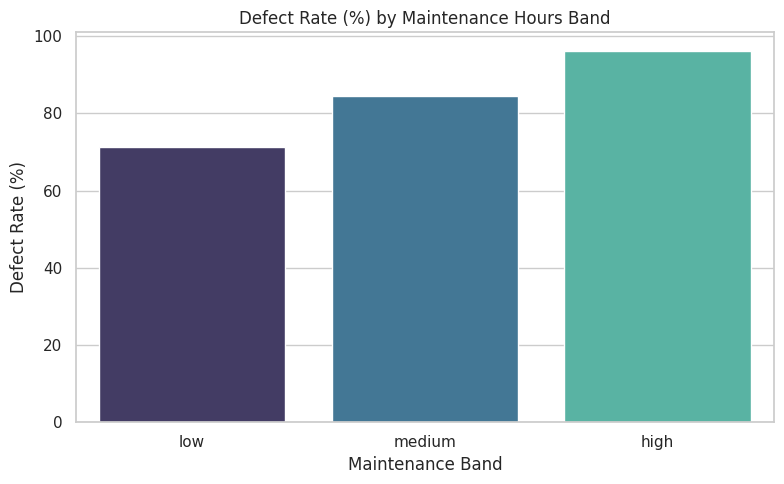

In [7]:
band_defect = df.groupby('maintenance_band')['DefectStatus'].mean().reindex(['low', 'medium', 'high']) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=band_defect.index, y=band_defect.values, palette='mako')
plt.title('Defect Rate (%) by Maintenance Hours Band')
plt.ylabel('Defect Rate (%)')
plt.xlabel('Maintenance Band')
plt.tight_layout()
plt.savefig('../outputs/defect_by_maintenance_band.png', dpi=120)
plt.show()


### 3.2 Quality Score & Supplier Quality vs. defect outcome

These are the two variables you'd intuitively expect to matter most.

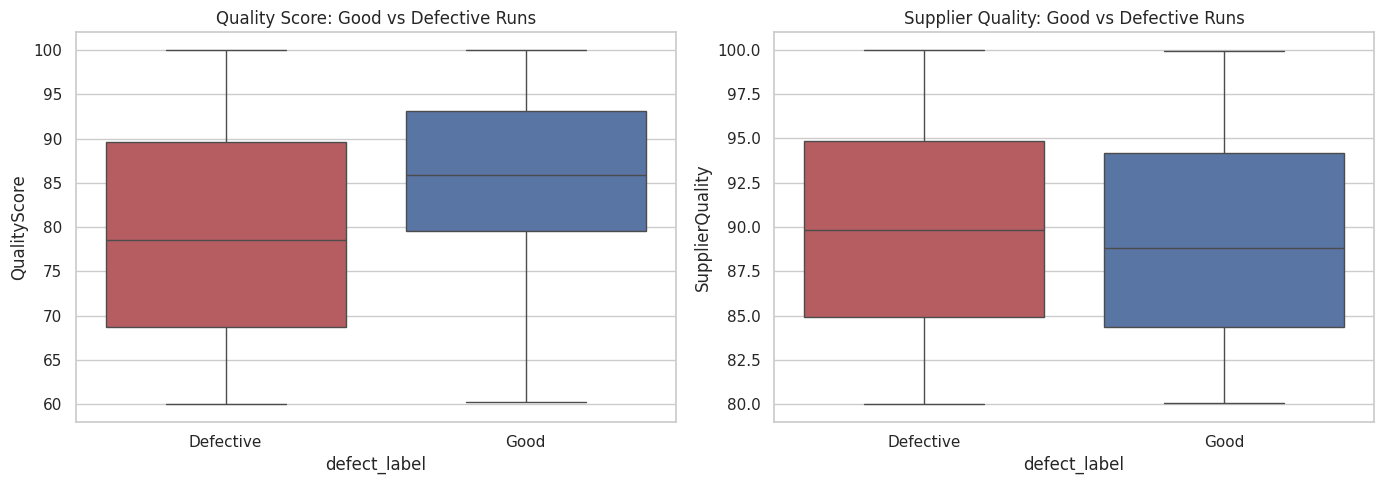

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='defect_label', y='QualityScore', hue='defect_label',
            palette={'Good': '#4C72B0', 'Defective': '#C44E52'}, legend=False, ax=axes[0])
axes[0].set_title('Quality Score: Good vs Defective Runs')

sns.boxplot(data=df, x='defect_label', y='SupplierQuality', hue='defect_label',
            palette={'Good': '#4C72B0', 'Defective': '#C44E52'}, legend=False, ax=axes[1])
axes[1].set_title('Supplier Quality: Good vs Defective Runs')

plt.tight_layout()
plt.savefig('../outputs/quality_vs_defect.png', dpi=120)
plt.show()


### 3.3 Correlation heatmap of process parameters

A quick way to see which numeric features move together before modeling,
and which ones actually correlate with `DefectStatus` itself.

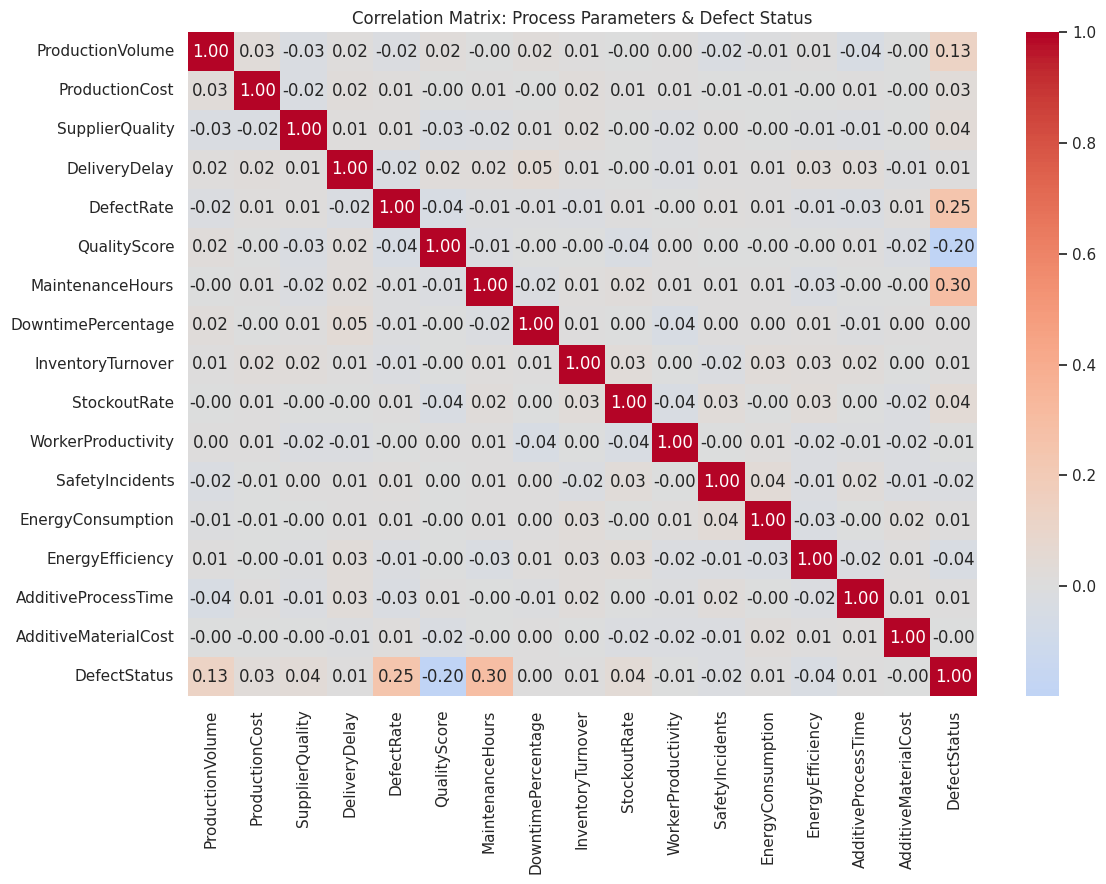

In [9]:
numeric_cols = ManufacturingDataset.RAW_FEATURES + ['DefectStatus']

plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Process Parameters & Defect Status')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=120)
plt.show()


### 3.4 Process health score distribution

The composite score engineered above, split by outcome.

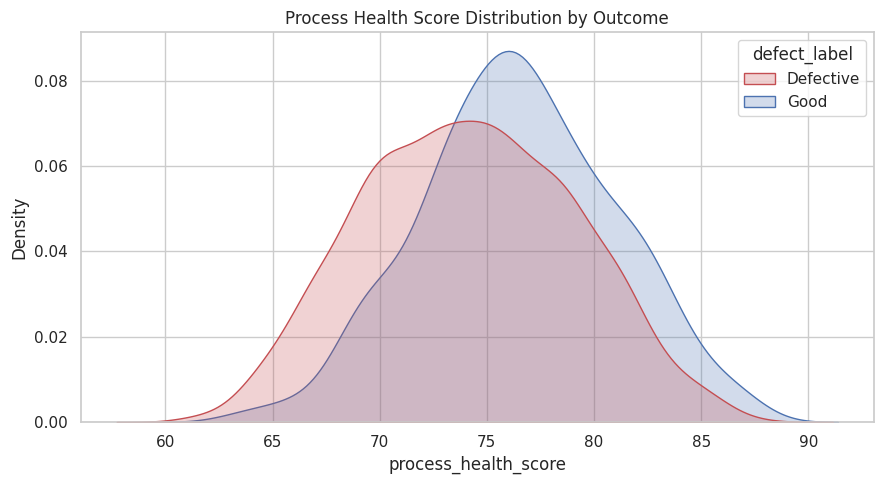

In [10]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='process_health_score', hue='defect_label',
            fill=True, common_norm=False, palette={'Good': '#4C72B0', 'Defective': '#C44E52'})
plt.title('Process Health Score Distribution by Outcome')
plt.tight_layout()
plt.savefig('../outputs/process_health_distribution.png', dpi=120)
plt.show()


### 3.5 Cost & energy efficiency per unit, by maintenance band

In [11]:
pivot = df.pivot_table(values=['cost_per_unit', 'energy_per_unit'],
                        index='maintenance_band', aggfunc='mean').reindex(['low', 'medium', 'high'])
pivot


,cost_per_unit,energy_per_unit
maintenance_band,,
low,31.449138,7.681464
medium,33.280131,7.873074
high,31.461906,7.758213


/tmp/ipykernel_507/1597591504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot.index, y=pivot['cost_per_unit'], ax=axes[0], palette='crest')
/tmp/ipykernel_507/1597591504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot.index, y=pivot['energy_per_unit'], ax=axes[1], palette='flare')


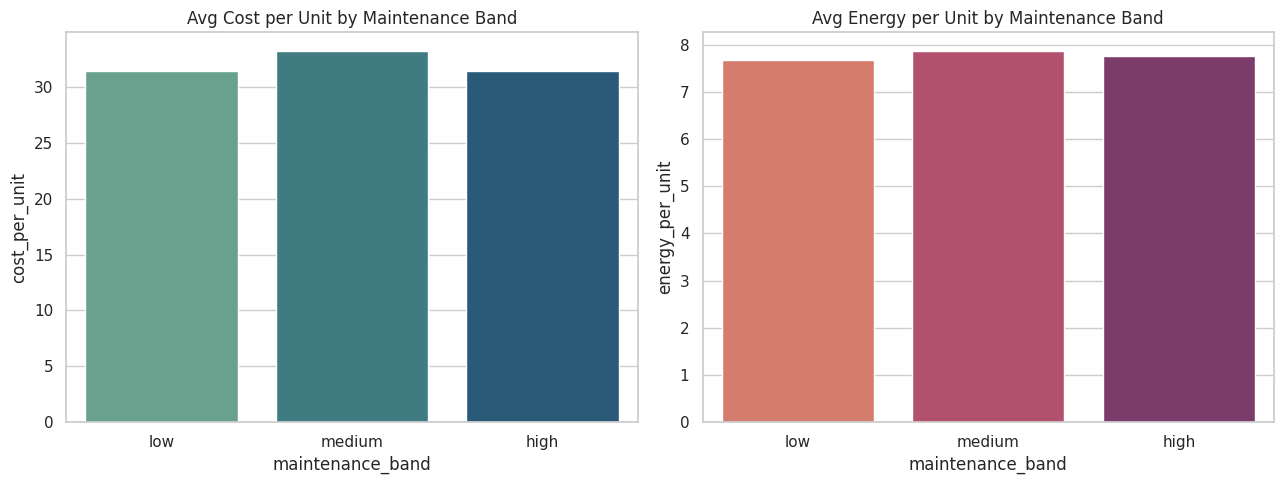

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=pivot.index, y=pivot['cost_per_unit'], ax=axes[0], palette='crest')
axes[0].set_title('Avg Cost per Unit by Maintenance Band')

sns.barplot(x=pivot.index, y=pivot['energy_per_unit'], ax=axes[1], palette='flare')
axes[1].set_title('Avg Energy per Unit by Maintenance Band')

plt.tight_layout()
plt.savefig('../outputs/cost_energy_by_band.png', dpi=120)
plt.show()


## 4. Machine Learning: Predicting Defect Status

**Goal:** predict `DefectStatus` from the 16 process parameters. We use a
`RandomForestClassifier` for its interpretable feature importances — useful
for telling a plant engineer *which knob to check first*.

Because the classes are imbalanced (~84/16), we use `class_weight='balanced'`
and look at precision/recall/F1 and ROC-AUC rather than raw accuracy.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay


In [14]:
X = df[ManufacturingDataset.RAW_FEATURES]
y = df[ManufacturingDataset.TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced', random_state=42
)
model.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [15]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Good', 'Defective']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


              precision    recall  f1-score   support

        Good       0.95      0.74      0.83       129
   Defective       0.95      0.99      0.97       681

    accuracy                           0.95       810
   macro avg       0.95      0.86      0.90       810
weighted avg       0.95      0.95      0.95       810

ROC-AUC: 0.841


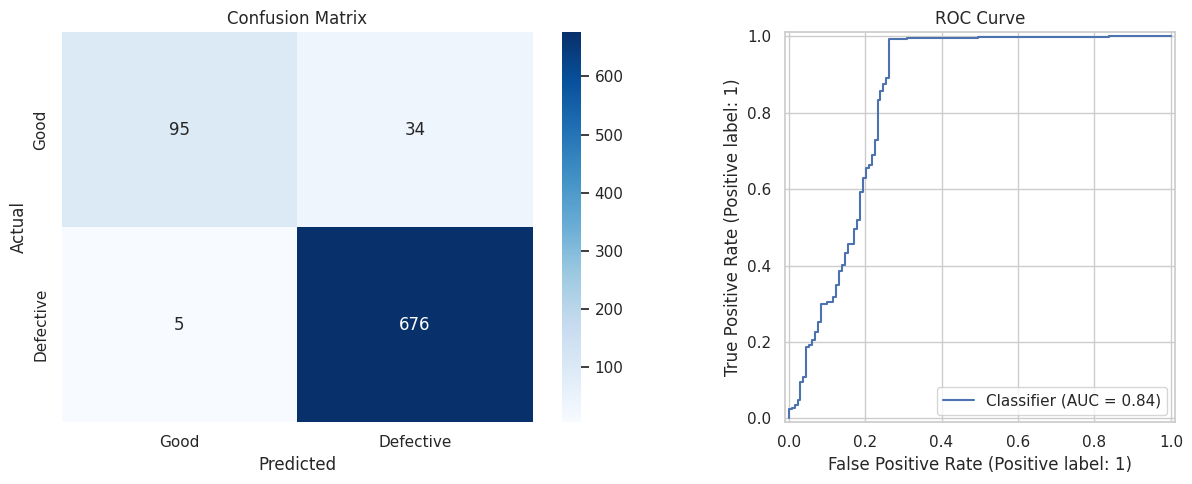

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Defective'], yticklabels=['Good', 'Defective'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('../outputs/model_evaluation.png', dpi=120)
plt.show()


### Feature importance

Which process parameters matter most for predicting a defect? This is the
single most actionable output of the notebook for a plant engineer.

/tmp/ipykernel_507/1176352886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


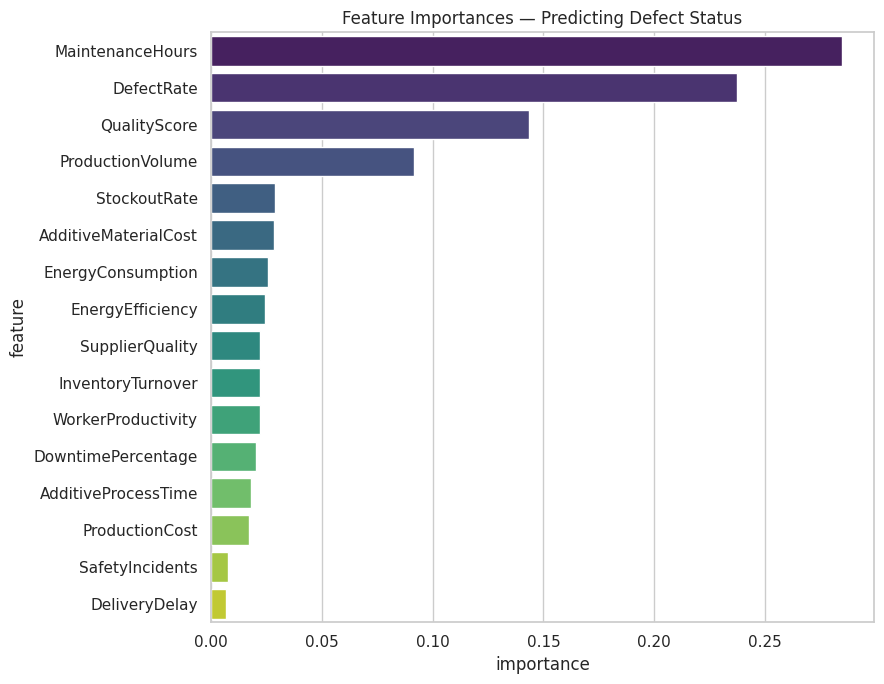

In [17]:
importance_df = pd.DataFrame({
    'feature': ManufacturingDataset.RAW_FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importances — Predicting Defect Status')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=120)
plt.show()


## 5. Business Takeaways

Summarizing what a plant supervisor could act on from this analysis
(numbers below are computed from the actual results above, not hardcoded):

In [18]:
top_feature = importance_df.iloc[0]['feature']
second_feature = importance_df.iloc[1]['feature']
worst_band = band_defect.idxmax()

print(f"1. Strongest predictor of defects (model) : {top_feature}")
print(f"2. Second strongest predictor              : {second_feature}")
print(f"3. Maintenance band with highest defect rate: {worst_band} ({band_defect.max():.1f}%)")
print(f"4. Model ROC-AUC on held-out test data      : {roc_auc_score(y_test, y_proba):.3f}")
print(f"5. Recall on the Defective class             : "
      f"{classification_report(y_test, y_pred, target_names=['Good','Defective'], output_dict=True)['Defective']['recall']:.2f}")


1. Strongest predictor of defects (model) : MaintenanceHours
2. Second strongest predictor              : DefectRate
3. Maintenance band with highest defect rate: high (96.2%)
4. Model ROC-AUC on held-out test data      : 0.841
5. Recall on the Defective class             : 0.99


**Suggested next steps for a real deployment:**
- Feed live process readings into the trained model for real-time defect
  risk scoring per production run
- Focus process-control effort on the top 2-3 features identified above,
  since they carry most of the model's predictive signal
- Investigate *why* certain maintenance bands correlate with higher defect
  rates — is it reactive maintenance happening only after problems appear?
- Retrain periodically as new production data comes in; process drift is
  common as equipment ages or suppliers change

---
*Dataset: [Predicting Manufacturing Defects Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predicting-manufacturing-defects-dataset)
by Rabie El Kharoua, via Kaggle.*
